In [1]:
from pathlib import Path

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

## Load data

In [2]:
dir_sample100 = Path('/projects/mtg/projects/sample-identification/datasets/sample100_withnoise')

path_csv_samples = dir_sample100 / 'meta' / 'samples.csv'
path_csv_tracks  = dir_sample100 / 'meta' / 'tracks.csv'

df_samples = pd.read_csv(
    path_csv_samples,
    delimiter=',',
    usecols=['sample_id', 'original_track_id', 'sample_track_id', 'sample_type'],
    encoding='latin-1'
)
df_tracks = pd.read_csv(path_csv_tracks)
df_tracks.columns = df_tracks.columns.str.strip()
df_tracks['track_id'] = df_tracks['track_id'].str.strip()

# deduplicate edges (multiple samples between same pair of tracks)
edges = df_samples[['original_track_id', 'sample_track_id']].drop_duplicates()
print(f'{len(df_samples)} sample rows → {len(edges)} unique edges')

106 sample rows → 90 unique edges


## Build directed graph

In [3]:
G = nx.DiGraph()

# add node attributes from tracks metadata
track_info = df_tracks.set_index('track_id')[['artist', 'title', 'year', 'genre']].to_dict('index')
for tid, attrs in track_info.items():
    G.add_node(tid, **{k: str(v).strip() for k, v in attrs.items()})

# edges: original_track_id --> sample_track_id
# (the original was sampled BY the sample track)
for _, row in edges.iterrows():
    G.add_edge(row['original_track_id'], row['sample_track_id'])

print(f'Nodes: {G.number_of_nodes()}  Edges: {G.number_of_edges()}')
print(f'Weakly connected components: {nx.number_weakly_connected_components(G)}')

Nodes: 144  Edges: 90
Weakly connected components: 54


## Basic graph statistics

In [4]:
# most-sampled originals (highest out-degree)
out_deg = sorted(G.out_degree(), key=lambda x: x[1], reverse=True)
print('Most-sampled originals:')
for tid, deg in out_deg[:10]:
    info = track_info.get(tid, {})
    print(f'  {tid} ({deg} samples) — {info.get("artist","?")}: {info.get("title","?")}')

print()

# tracks that sample the most (highest in-degree)
in_deg = sorted(G.in_degree(), key=lambda x: x[1], reverse=True)
print('Tracks built from the most sources:')
for tid, deg in in_deg[:10]:
    if deg == 0:
        break
    info = track_info.get(tid, {})
    print(f'  {tid} ({deg} sources) — {info.get("artist","?")}: {info.get("title","?")}')

Most-sampled originals:
  T083 (5 samples) —  James Brown:  Funky Drummer
  T052 (4 samples) —  Lee Dorsey:  Get Out of My Life Woman
  T090 (3 samples) —  The Honey Drippers:  Impeach The President
  T098 (3 samples) —  Five Stairsteps:  Don't Change Your Love
  T145 (3 samples) —  Barry White:  I'm gonna love you just a little more baby
  T033 (2 samples) —  The Emotions:  Blind Alley
  T045 (2 samples) —  The J.B.'s:  The Grunt
  T085 (2 samples) —  Isaac Hayes:  The Breakthrough
  T088 (2 samples) —  Funkadelic:  You'll like it too
  T116 (2 samples) —  The Winstons:  Amen Brother

Tracks built from the most sources:
  T037 (3 sources) —  De La Soul:  Eye Know
  T048 (3 sources) —  De La Soul:  Change in Speak
  T093 (3 sources) —  Kris Kross:  Jump
  T184 (3 sources) —  Nas:  Get Down
  T039 (2 sources) —  Biz Markie:  Just a Friend
  T054 (2 sources) —  Public Enemy:  Rebel Without a Pause
  T086 (2 sources) —  NWA:  Straight outta Compton
  T110 (2 sources) —  Ghostface Killah &

## Visualize — full graph (spring layout, colour by genre)

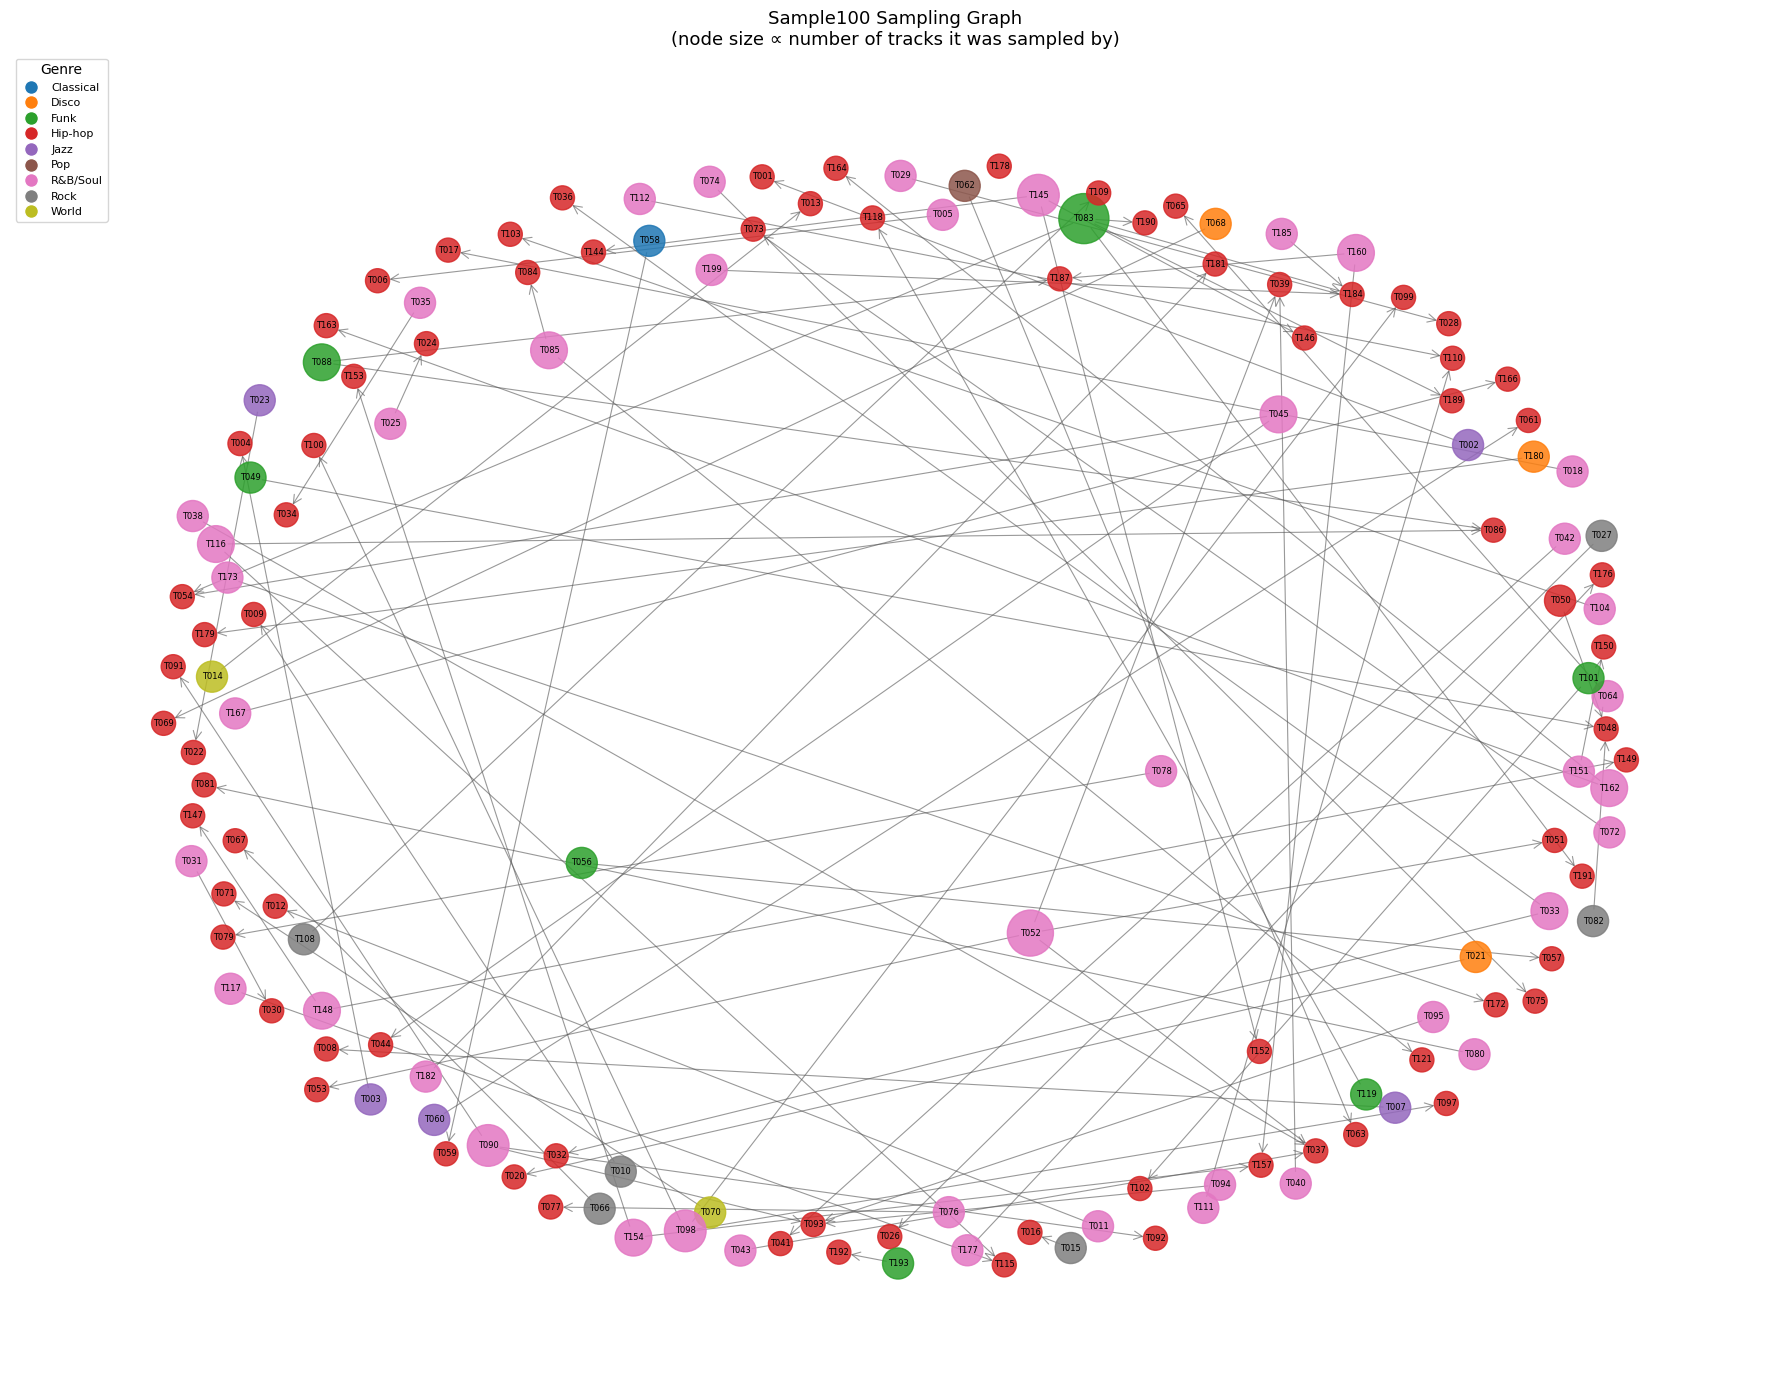

In [5]:
genres = sorted({d.get('genre', 'Unknown') for _, d in G.nodes(data=True)})
palette = plt.cm.tab10.colors
genre_color = {g: palette[i % len(palette)] for i, g in enumerate(genres)}

node_colors = [genre_color.get(G.nodes[n].get('genre', 'Unknown'), 'grey') for n in G.nodes()]
node_sizes  = [300 + 200 * G.out_degree(n) for n in G.nodes()]

pos = nx.spring_layout(G, seed=42, k=1.5)

fig, ax = plt.subplots(figsize=(18, 14))
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, alpha=0.85, ax=ax)
nx.draw_networkx_edges(G, pos, edge_color='#555', arrows=True,
                       arrowstyle='->', arrowsize=15, width=0.8, alpha=0.6, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=6, ax=ax)

# legend
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c,
                      markersize=10, label=g) for g, c in genre_color.items()]
ax.legend(handles=handles, title='Genre', loc='upper left', fontsize=8)
ax.set_title('Sample100 Sampling Graph\n(node size ∝ number of tracks it was sampled by)', fontsize=13)
ax.axis('off')
plt.tight_layout()
plt.savefig('sampling_graph_full.png', dpi=150)
plt.show()

## Visualize — largest weakly connected component only

Largest WCC: 10 nodes, 9 edges


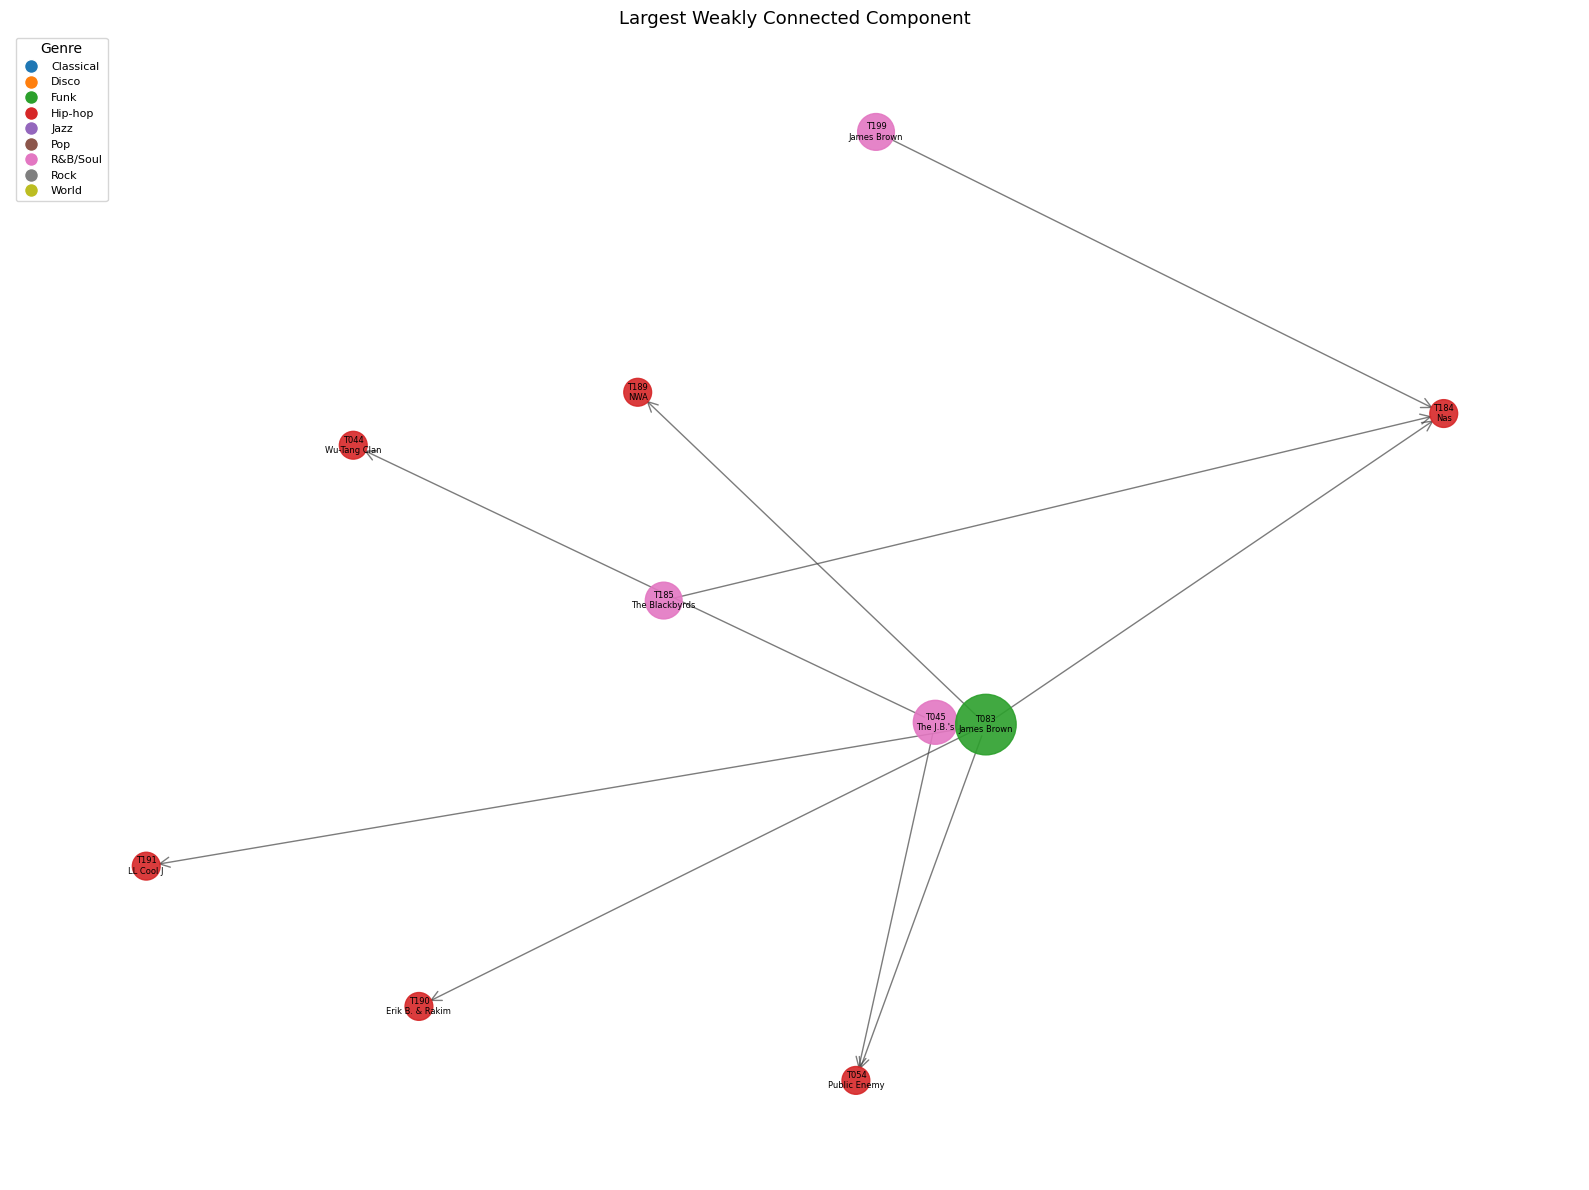

In [6]:
largest_wcc = max(nx.weakly_connected_components(G), key=len)
H = G.subgraph(largest_wcc).copy()
print(f'Largest WCC: {H.number_of_nodes()} nodes, {H.number_of_edges()} edges')

node_colors_h = [genre_color.get(H.nodes[n].get('genre', 'Unknown'), 'grey') for n in H.nodes()]
node_sizes_h  = [400 + 300 * H.out_degree(n) for n in H.nodes()]

pos_h = nx.kamada_kawai_layout(H)

fig, ax = plt.subplots(figsize=(16, 12))
nx.draw_networkx_nodes(H, pos_h, node_color=node_colors_h, node_size=node_sizes_h, alpha=0.9, ax=ax)
nx.draw_networkx_edges(H, pos_h, edge_color='#444', arrows=True,
                       arrowstyle='->', arrowsize=18, width=1.0, alpha=0.7, ax=ax)
labels_h = {n: f"{n}\n{H.nodes[n].get('artist','')[:15]}" for n in H.nodes()}
nx.draw_networkx_labels(H, pos_h, labels=labels_h, font_size=6, ax=ax)

handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c,
                      markersize=10, label=g) for g, c in genre_color.items()]
ax.legend(handles=handles, title='Genre', loc='upper left', fontsize=8)
ax.set_title('Largest Weakly Connected Component', fontsize=13)
ax.axis('off')
plt.tight_layout()
plt.savefig('sampling_graph_lcc.png', dpi=150)
plt.show()